In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from Analysis import (
    SpatiotemporalAnalysis,demodulate
)
from matplotlib.lines import Line2D

Fogi timing

In [2]:
cd = "CDK174"
ctrl_path = f"D:\\K_Sunada\\result\\{cd}\\"

result_dict_tx = dict(
    data_ph0 = dict(target_freq=9.35, date="2025-02-18", acquire_time="105702", duration=1000),
    data_ph1 = dict(target_freq=9.35, date="2025-02-18", acquire_time="105752", duration=1000),
    data_ph2 = dict(target_freq=9.35, date="2025-02-18", acquire_time="105842", duration=1000),
    data_ph3 = dict(target_freq=9.35, date="2025-02-18", acquire_time="105932", duration=1000),
)

result_dict_rx = dict(
    data_ph0 = dict(target_freq=9.35, date="2025-02-18", acquire_time="163203", duration=1000),
    data_ph1 = dict(target_freq=9.35, date="2025-02-18", acquire_time="163240", duration=1000),
    data_ph2 = dict(target_freq=9.35, date="2025-02-18", acquire_time="163317", duration=1000),
    data_ph3 = dict(target_freq=9.35, date="2025-02-18", acquire_time="163355", duration=1000),
)

delay -61.0
delay -84.0
delay -125.0
delay 127.0


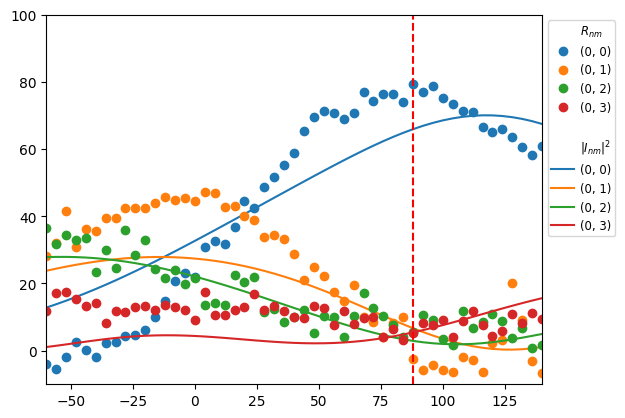

In [3]:
header = "D:/K_sunada/result/CDK174/"
ph0_fo0 = "/2025-02-18/2025-02-18T164017_9956fde1-j1_JPA_comm_timing"
ph0_fo1 = "/2025-02-18/2025-02-18T174445_9ad4f82c-j1_JPA_comm_timing"
ph0_fo2 = "/2025-02-18/2025-02-18T184926_a3eff92d-j1_JPA_comm_timing"
ph0_fo3 = "/2025-02-18/2025-02-18T195500_ccc4e0e8-j1_JPA_comm_timing"

num_of_ph_amp = 1
num_of_fogi_timing = 51
f_if = (9.47-9.35)*1e9

acquisition_00 = SpatiotemporalAnalysis(ctrl_path, ph0_fo0, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_01 = SpatiotemporalAnalysis(ctrl_path, ph0_fo1, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_02 = SpatiotemporalAnalysis(ctrl_path, ph0_fo2, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_03 = SpatiotemporalAnalysis(ctrl_path, ph0_fo3, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots()
acquisition_00.plot_results(ax, label="ph_0 & fogi_0", color="tab:blue", fitting=True)
acquisition_01.plot_results(ax, label="ph_0 & fogi_1", color="tab:orange", fitting=True)
acquisition_02.plot_results(ax, label="ph_0 & fogi_2", color="tab:green", fitting=True)
acquisition_03.plot_results(ax, label="ph_0 & fogi_3", color="tab:red", fitting=True)

ax.set_ylim(-10, 100)
ax.set_xlim(-60, 140)
ax.vlines(88, -10, 100, color="r", linestyle="dashed")
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(0, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(0, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(0, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"),
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(0, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(0, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(0, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1, fontsize="small", 
           handletextpad=0.5,borderpad=0.3)
plt.show()

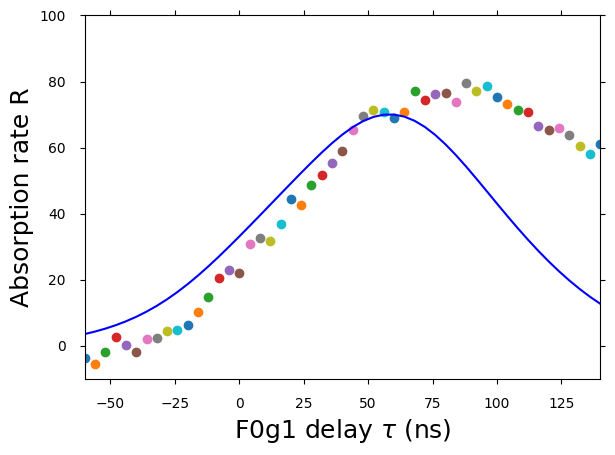

In [4]:
from datataking import search_datadict_miyamura
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
readout_lo_freq = 9.47
passing_band = 0.01
duration=1000
cd = "CDK174"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"
signals_tx = []
for k, v in result_dict_tx.items():
    # fig = plt.figure(figsize=(8, 2))
    # ax = fig.add_subplot(1, 2, 1)
    # ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    # ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    # ax.plot(photon_freq, np.abs(fourier))
    # ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    # ax.set_xlim(9.32, 9.38)
    # ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    norm=np.sum(2*np.abs(signal)**2)**0.5
    signals_tx.append(signal/norm)
    # res = fit_waveform(time, np.abs(signal), curve="sech_3", kappa=const)
    # ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    # ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    # ax2.plot(time, signal.real, label="real")
    # ax2.plot(time, signal.imag, label="imag")
    # ax2.set_xlabel("Time (ns)")
    # ax2.set_xlim(0, 1000)

signals_rx = []
for k, v in result_dict_rx.items():
    # fig = plt.figure(figsize=(8, 2))
    # ax = fig.add_subplot(1, 2, 1)
    # ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    # ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    # ax.plot(photon_freq, np.abs(fourier))
    # ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    # ax.set_xlim(9.32, 9.38)
    # ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    norm=np.sum(2*np.abs(signal)**2)**0.5
    signals_rx.append(signal/norm)
    # res = fit_waveform(time, np.abs(signal), curve="sech_3", kappa=const)
    # ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    # ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    # ax2.plot(time, signal.real, label="real")
    # ax2.plot(time, signal.imag, label="imag")
    # ax2.set_xlabel("Time (ns)")
    # ax2.set_xlim(0, 1000)

signal_ph0_tx, signal_ph1_tx, signal_ph2_tx, signal_ph3_tx = signals_tx[0], signals_tx[1], signals_tx[2], signals_tx[3]
signal_ph0_rx, signal_ph1_rx, signal_ph2_rx, signal_ph3_rx = signals_rx[0][::-1], signals_rx[1][::-1], signals_rx[2][::-1], signals_rx[3][::-1]

def roll_with_zeros(array, shift):
    if shift > 0:
        rolled = np.roll(array, shift)
        rolled[:shift] = 0 
    elif shift < 0:
        rolled = np.roll(array, shift)
        rolled[shift:] = 0 
    else:
        rolled = array
    return rolled

def overlap_comm(data_tx, data_rx, taus, time):
    ys = []
    for tau in taus:
        shifted_data_rx = roll_with_zeros(data_rx, shift=tau)
        new_func = data_tx * shifted_data_rx
        y = np.abs(np.sum(new_func) * 2)**2
        ys.append(y)
    return np.array(ys) * 100
taus = np.linspace(-100, 100, 51, dtype=int)
data_t = np.linspace(0, 1000, 501)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
ax1.set_ylim(-10, 100)
ax1.set_xlim(-60, 140)
plt.tight_layout()
plt.plot(acquisition_00.get_results()["fogi_delay"], acquisition_00.get_results()["rates"], "o", label= "ph_0 & fogi_0")
# plt.plot(time01, ph0fo1, "o", label= "ph_0 & fogi_1")
# plt.plot(time02, ph0fo2, "o", label= "ph_0 & fogi_2")
# plt.plot(time03, ph0fo3, "o", label= "ph_0 & fogi_3")
plt.plot(acquisition_00.get_results()["fogi_delay"][0], overlap_comm(signal_ph0_tx, signal_ph0_rx, taus+10, data_t), color="b")
# plt.plot(time00, overlap_comm(signal_ph0_tx, signal_ph1_rx, taus+30, data_t), color="orange")
# plt.plot(time00, overlap_comm(signal_ph0_tx, signal_ph2_rx, taus+30, data_t), color="g")
# plt.plot(time00, overlap_comm(signal_ph0_tx, signal_ph3_rx, taus+30, data_t), color="r")
# plt.legend()
plt.show()

79.47157229443084


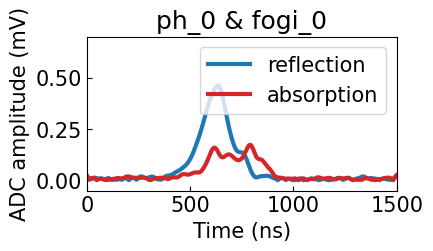

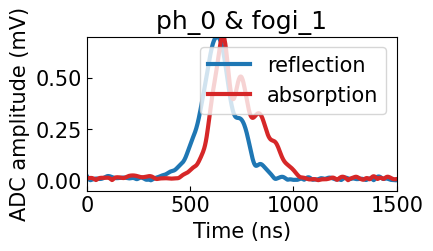

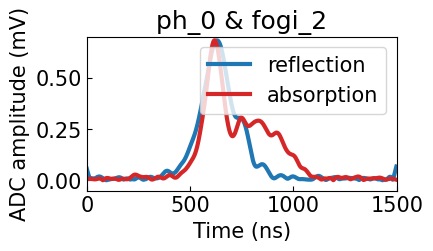

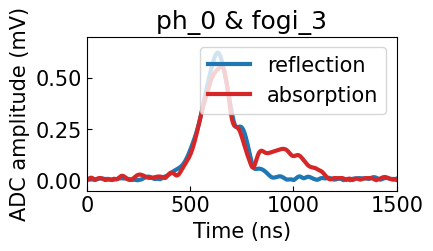

In [5]:
ph_amp = 0
fogi_freq = 37

fig, ax = plt.subplots(figsize=(4, 2))
acquisition_00.plot_waveform(ax=ax, title="ph_0 & fogi_0", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_01.plot_waveform(ax=ax, title="ph_0 & fogi_1", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_02.plot_waveform(ax=ax, title="ph_0 & fogi_2", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_03.plot_waveform(ax=ax, title="ph_0 & fogi_3", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)

print(acquisition_00.get_results()["rates"][0][fogi_freq])
plt.show()


phototn 1

delay -79.0
delay -49.0


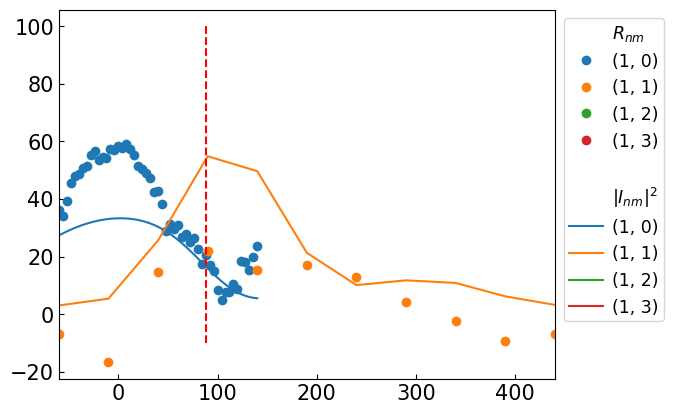

In [6]:
ph1_fo0 = "/2025-02-18/2025-02-18T210035_f65b6a61-j1_JPA_comm_timing"
# ph1_fo1 = "/2025-02-18/2025-02-18T220544_101b57b3-j1_JPA_comm_timing"
ph1_fo1 = "/2025-02-19/2025-02-19T105714_d6eb442e-j1_JPA_comm_timing"
# ph1_fo2 = "/2025-02-18/2025-02-18T231118_390af4cf-j1_JPA_comm_timing"
# ph1_fo3 = "/2025-02-19/2025-02-19T001648_5f318d79-j1_JPA_comm_timing"

acquisition_10 = SpatiotemporalAnalysis(ctrl_path, ph1_fo0, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_11 = SpatiotemporalAnalysis(ctrl_path, ph1_fo1, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
# acquisition_12 = SpatiotemporalAnalysis(ctrl_path, ph1_fo2, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
# acquisition_13 = SpatiotemporalAnalysis(ctrl_path, ph1_fo3, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots()
acquisition_10.plot_results(ax, label="ph_1 & fogi_0", color="tab:blue", fitting=True)
acquisition_11.plot_results(ax, label="ph_1 & fogi_1", color="tab:orange", fitting=True)
# acquisition_12.plot_results(ax, label="ph_1 & fogi_2", color="tab:green", fitting=True)
# acquisition_13.plot_results(ax, label="ph_1 & fogi_3", color="tab:red", fitting=True)

# ax.set_ylim(-10, 100)
ax.set_xlim(-60, 440)
plt.vlines(88, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"), 
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(1, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(1, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(1, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(1, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"), 
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(1, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(1, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(1, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(1, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )
plt.show()

IndexError: index 20 is out of bounds for axis 0 with size 11

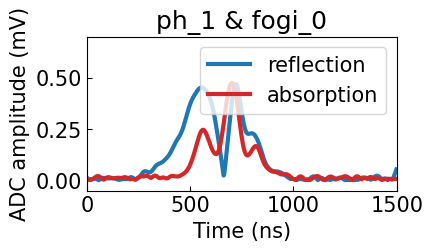

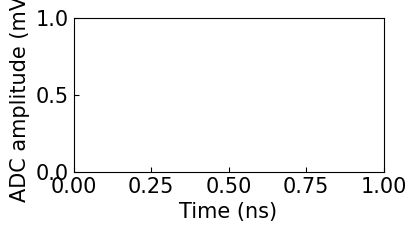

In [7]:
ph_amp = 0
fogi_freq = 20

fig, ax = plt.subplots(figsize=(4, 2))
acquisition_10.plot_waveform(ax=ax, title="ph_1 & fogi_0", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_11.plot_waveform(ax=ax, title="ph_1 & fogi_1", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_12.plot_waveform(ax=ax, title="ph_1 & fogi_2", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_13.plot_waveform(ax=ax, title="ph_1 & fogi_3", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)

plt.show()

phototn 2

delay -54.0
delay -101.0
delay -102.0
delay -38.0


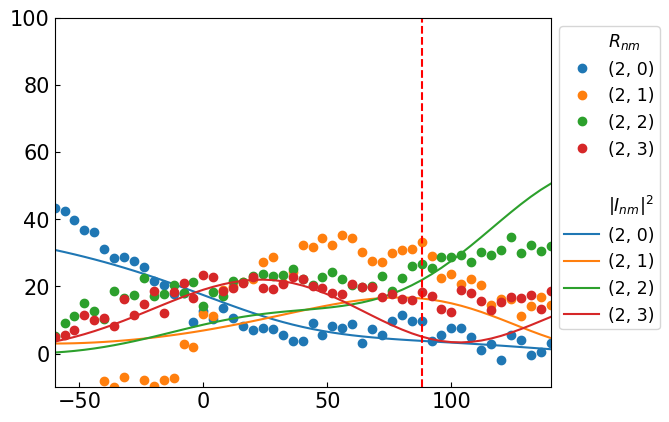

In [11]:
ph2_fo0 = "/2025-02-19/2025-02-19T012147_7394f525-j1_JPA_comm_timing"
ph2_fo1 = "/2025-02-19/2025-02-19T022722_9cecdf49-j1_JPA_comm_timing"
ph2_fo2 = "/2025-02-19/2025-02-19T033304_caabbaa5-j1_JPA_comm_timing"
ph2_fo3 = "/2025-02-19/2025-02-19T043903_027e55af-j1_JPA_comm_timing"

acquisition_20 = SpatiotemporalAnalysis(header, ph2_fo0, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_21 = SpatiotemporalAnalysis(header, ph2_fo1, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_22 = SpatiotemporalAnalysis(header, ph2_fo2, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_23 = SpatiotemporalAnalysis(header, ph2_fo3, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots()
acquisition_20.plot_results(ax, label="ph_2 & fogi_0", color="tab:blue", fitting=True)
acquisition_21.plot_results(ax, label="ph_2 & fogi_1", color="tab:orange", fitting=True)
acquisition_22.plot_results(ax, label="ph_2 & fogi_2", color="tab:green", fitting=True)
acquisition_23.plot_results(ax, label="ph_2 & fogi_3", color="tab:red", fitting=True)

ax.set_ylim(-10, 100)
ax.set_xlim(-60, 140)
plt.vlines(88, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(2, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(2, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(2, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(2, 3)"),
    Line2D([0], [0], color="none", marker="", label=""), 
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"), 
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(2, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(2, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(2, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(2, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3)
plt.show()

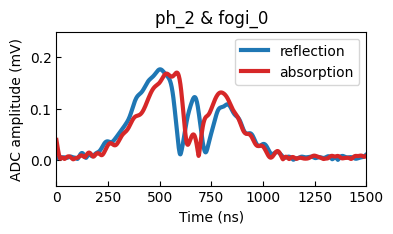

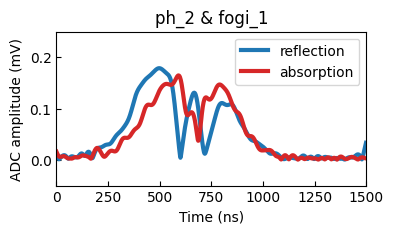

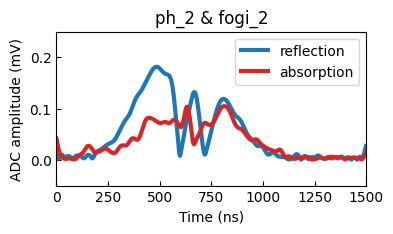

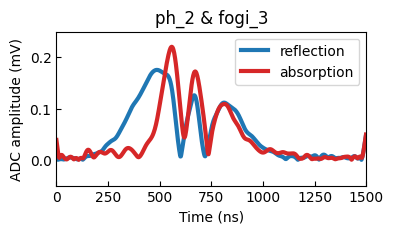

In [9]:
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(figsize=(4, 2))
acquisition_20.plot_waveform(ax=ax, title="ph_2 & fogi_0", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_21.plot_waveform(ax=ax, title="ph_2 & fogi_1", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_22.plot_waveform(ax=ax, title="ph_2 & fogi_2", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_23.plot_waveform(ax=ax, title="ph_2 & fogi_3", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)

plt.show()

phototn 3

delay -36.0
delay -68.0


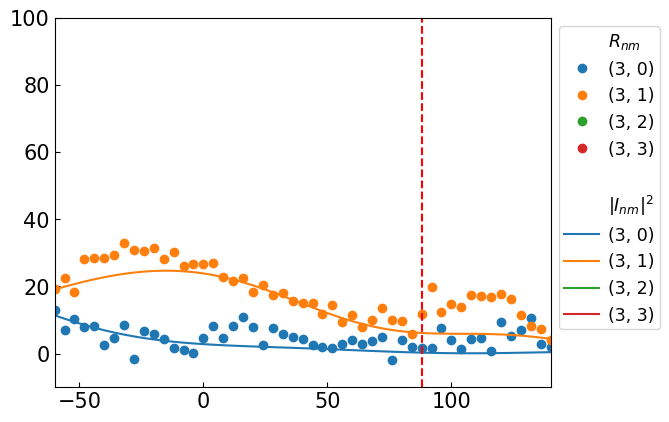

In [12]:
ph3_fo0 = "/2025-02-19/2025-02-19T054443_2ebfaf8a-j1_JPA_comm_timing"
ph3_fo1 = "/2025-02-19/2025-02-19T065059_705278cb-j1_JPA_comm_timing"
ph3_fo2 = "/2024-11-15/2024-11-15T193127_c4ffe89d-j1_JPA_comm_timing"
ph3_fo3 = "/2024-11-15/2024-11-15T205353_4908ffd0-j1_JPA_comm_timing"

acquisition_30 = SpatiotemporalAnalysis(header, ph3_fo0, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_31 = SpatiotemporalAnalysis(header, ph3_fo1, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
# acquisition_32 = SpatiotemporalAnalysis(header, ph3_fo2, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
# acquisition_33 = SpatiotemporalAnalysis(header, ph3_fo3, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots()
acquisition_30.plot_results(ax, label="ph_3 & fogi_0", color="tab:blue", fitting=True)
acquisition_31.plot_results(ax, label="ph_3 & fogi_1", color="tab:orange", fitting=True)
# acquisition_32.plot_results(ax, label="ph_3 & fogi_2", color="tab:green", fitting=True)
# acquisition_33.plot_results(ax, label="ph_3 & fogi_3", color="tab:red", fitting=True)

ax.set_ylim(-10, 100)
ax.set_xlim(-60, 140)
plt.vlines(88, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(3, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(3, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(3, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(3, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"),
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(3, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(3, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(3, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(3, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )
plt.show()

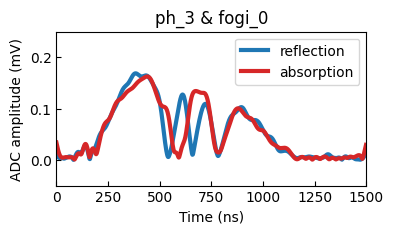

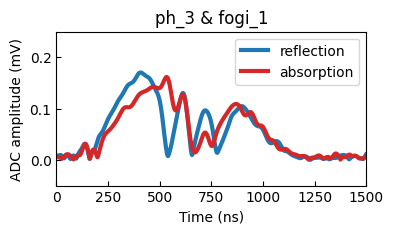

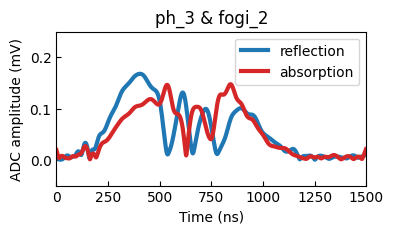

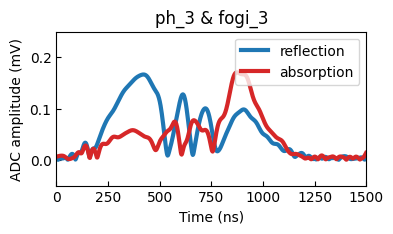

In [9]:
ph_amp = 0
fogi_freq = 30

fig, ax = plt.subplots(figsize=(4, 2))
acquisition_30.plot_waveform(ax=ax, title="ph_3 & fogi_0", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_31.plot_waveform(ax=ax, title="ph_3 & fogi_1", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_32.plot_waveform(ax=ax, title="ph_3 & fogi_2", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
fig, ax = plt.subplots(figsize=(4, 2))
acquisition_33.plot_waveform(ax=ax, title="ph_3 & fogi_3", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)

plt.show()

## analysis

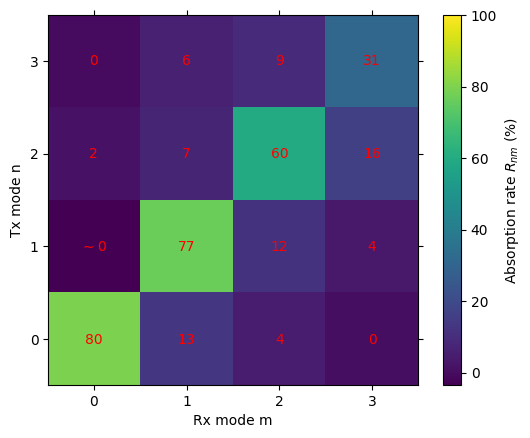

In [12]:
i = 30
data = np.array([[acquisition_30.get_results()["rates"][0][i], acquisition_31.get_results()["rates"][0][i], acquisition_32.get_results()["rates"][0][i], acquisition_33.get_results()["rates"][0][i]],
                [acquisition_20.get_results()["rates"][0][i], acquisition_21.get_results()["rates"][0][i], acquisition_22.get_results()["rates"][0][i], acquisition_23.get_results()["rates"][0][i]],
                [acquisition_10.get_results()["rates"][0][i], acquisition_11.get_results()["rates"][0][i], acquisition_12.get_results()["rates"][0][i], acquisition_13.get_results()["rates"][0][i]],
                [acquisition_00.get_results()["rates"][0][i], acquisition_01.get_results()["rates"][0][i], acquisition_02.get_results()["rates"][0][i], acquisition_03.get_results()["rates"][0][i]]])
SpatiotemporalAnalysis.plot_absorption_rate_matrix(data)

orthogonality

In [8]:
def overlap(func1, func2):
    i = 0
    for t in range(len(func1)):
        i += func1[t] * np.conjugate(func2[t])
    return np.abs(i)

In [9]:
def waveform_complex(data):
    time = data.get_results()["time"][ph_amp][fogi_freq]
    waveform = data.get_results()["waveform"][ph_amp][fogi_freq]
    phase = np.angle(demodulate(time, waveform, f_if*1e-9))
    waveform_complex = waveform * np.exp(-1j*phase)

    waveform_wo_fogi = data.get_results()["waveform_zero_fogi"][ph_amp][fogi_freq]
    phase_wo_fogi = np.angle(demodulate(time, waveform_wo_fogi, f_if*1e-9))
    waveform_complex_wo_fogi = waveform_wo_fogi * np.exp(-1j*phase_wo_fogi)
    return time, waveform_complex, waveform_complex_wo_fogi

NameError: name 'acquisition_30' is not defined

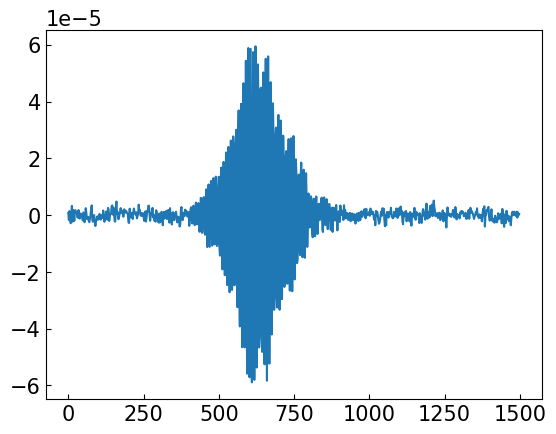

In [77]:
plt.plot(waveform_complex(acquisition_00)[0], waveform_complex(acquisition_00)[2].real )
plt.plot(waveform_complex(acquisition_00)[0], waveform_complex(acquisition_30)[2].real )

C:\Users\qipe\AppData\Local\Temp\ipykernel_13604\3688789986.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0.05, 0.05, 0, 0.95])


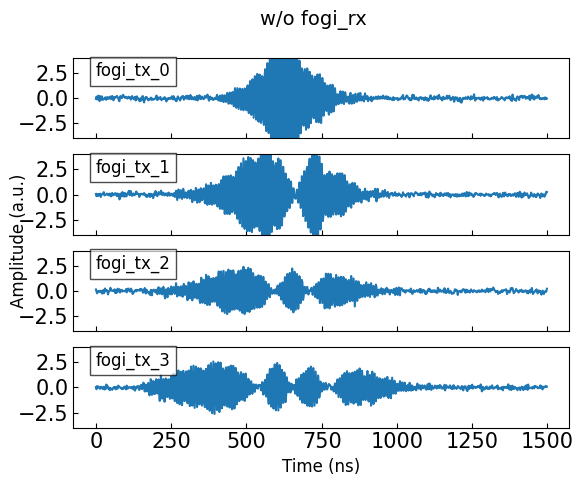

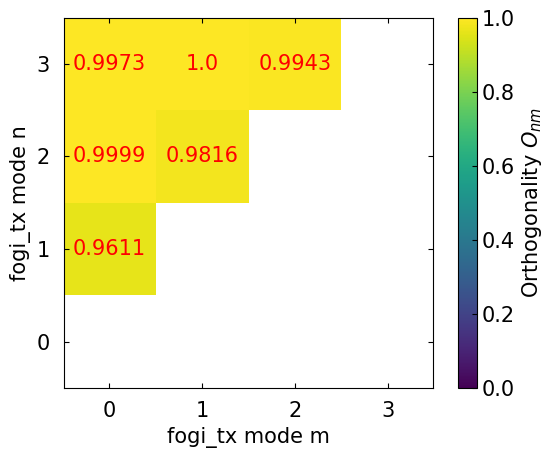

In [13]:
time = waveform_complex(acquisition_00)[0]

fig, ax = plt.subplots(nrows=4, sharex=True)
fig.suptitle("w/o fogi_rx", fontsize=14) 
datasets = [acquisition_00, acquisition_10, acquisition_20, acquisition_30]
for i in range(4):
    y_data = datasets[i].get_results()["waveform_zero_fogi"][ph_amp][fogi_freq]
    ax[i].plot(time, y_data*1e4)
    ax[i].tick_params(labelbottom=(i == 3))
    ax[i].set_ylim(-4, 4) 
    ax[i].text(time.min(), ax[i].get_ylim()[1] * 0.9, f"fogi_tx_{i}",
               fontsize=12, ha="left", va="top",
               bbox=dict(facecolor="white", alpha=0.7))
ax[3].set_xlabel("Time (ns)", fontsize=12) 
fig.text(0.04, 0.5, "Amplitude (a.u.)", va="center", ha="center", rotation=90, fontsize=12)
plt.tight_layout(rect=[0.05, 0.05, 0, 0.95])
plt.show()

##################
m = overlap(waveform_complex(acquisition_00)[2], waveform_complex(acquisition_00)[2])
oth_01 = np.sqrt(1-(overlap(waveform_complex(acquisition_00)[2], waveform_complex(acquisition_10)[2])/m)**2)
oth_02 = np.sqrt(1-(overlap(waveform_complex(acquisition_00)[2], waveform_complex(acquisition_20)[2])/m)**2)
oth_03 = np.sqrt(1-(overlap(waveform_complex(acquisition_00)[2], waveform_complex(acquisition_30)[2])/m)**2)
oth_12 = np.sqrt(1-(overlap(waveform_complex(acquisition_10)[2], waveform_complex(acquisition_20)[2])/m)**2)
oth_13 = np.sqrt(1-(overlap(waveform_complex(acquisition_10)[2], waveform_complex(acquisition_30)[2])/m)**2)
oth_23 = np.sqrt(1-(overlap(waveform_complex(acquisition_20)[2], waveform_complex(acquisition_30)[2])/m)**2)

data = np.array([[oth_03, oth_13, oth_23, np.nan],
        [oth_02, oth_12, np.nan, np.nan],
        [oth_01, np.nan, np.nan, np.nan],
        [np.nan, np.nan, np.nan, np.nan]])
extent = (0, 3, 0, 3)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.imshow(data, extent=extent, filternorm=False, vmin=0, vmax=1)
colorbar = plt.colorbar(label="Orthogonality $O_{nm}$")
colorbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.ylabel("fogi_tx mode n")
plt.xlabel("fogi_tx mode m")

num_x_ticks = data.shape[1]
num_y_ticks = data.shape[0]
x_ticks = np.linspace(extent[0] + 0.37, extent[1] - 0.37, num_x_ticks)
y_ticks = np.linspace(extent[2] + 0.37, extent[3] - 0.37, num_y_ticks)
plt.xticks(x_ticks, range(num_x_ticks))
plt.yticks(y_ticks, range(num_y_ticks))
for i in range(num_y_ticks):
    for j in range(num_x_ticks):
        if j < 3-i:
            plt.text(x_ticks[i], 3-y_ticks[j], f"{np.round(data[j, i], decimals=4)}", ha='center', va='center', color="red")

plt.show()

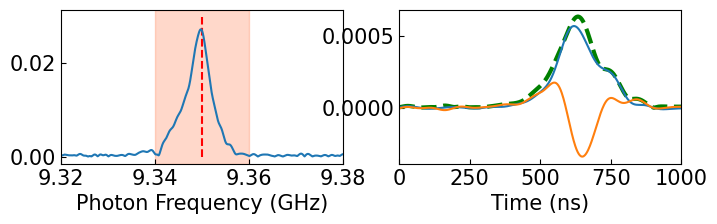

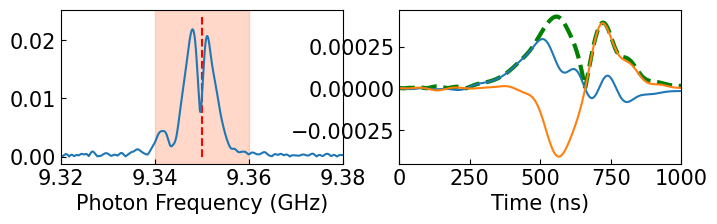

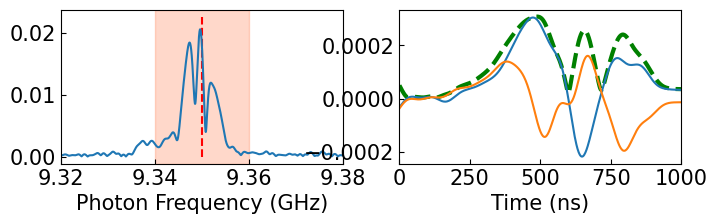

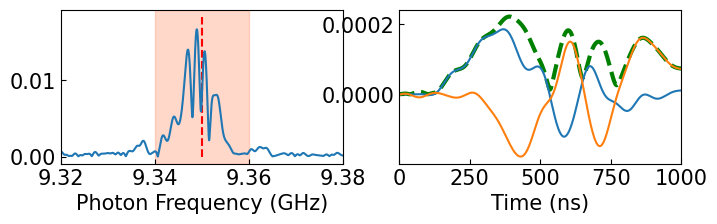

In [18]:
result_dict = dict(
    data0 = dict(target_freq=9.35, date="2025-02-18", acquire_time="164017"),
    data1 = dict(target_freq=9.35, date="2025-02-18", acquire_time="210035"),
    data2 = dict(target_freq=9.35, date="2025-02-19", acquire_time="012147"),
    data3 = dict(target_freq=9.35, date="2025-02-19", acquire_time="054443"),
)
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"][0].ravel()
    waveform = datadict["waveform_wo_fogi_rx"]["values"][0].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    # res = fit_waveform(time, np.abs(signal), curve="sech_2", kappa=const)
    # ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    # print(f"overlap {target_overlap(signal, time, curve='sech_2')}")
    # print(f"symmetry {IQ_sym_abs(signal, time)}, overlap {target_overlap(signal, time, curve='sech_1')}")
# plt.legend()

C:\Users\qipe\AppData\Local\Temp\ipykernel_18536\469667484.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0.05, 0.05, 0, 0.95])


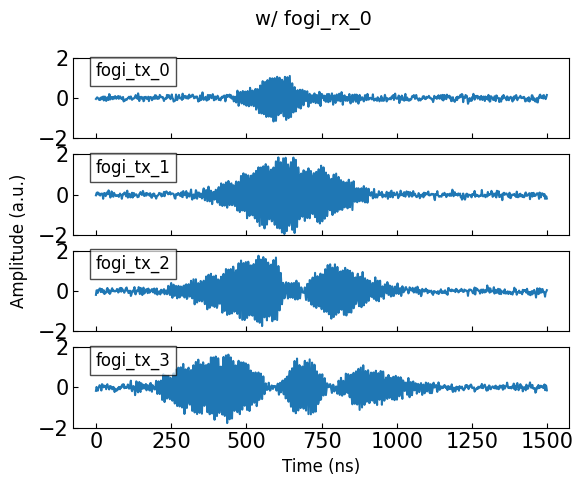

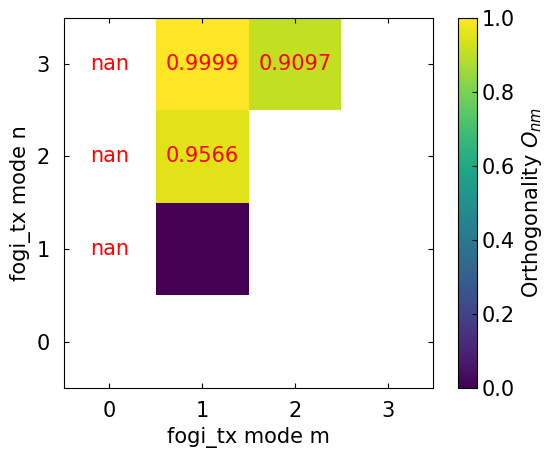

In [22]:
time = waveform_complex(acquisition_10)[0]

fig, ax = plt.subplots(nrows=4, sharex=True)
fig.suptitle("w/ fogi_rx_0", fontsize=14) 
datasets = [acquisition_00, acquisition_10, acquisition_20, acquisition_30]
for i in range(4):
    y_data = datasets[i].get_results()["waveform"][ph_amp][fogi_freq]
    ax[i].plot(time, y_data*1e4)
    ax[i].tick_params(labelbottom=(i == 3))
    ax[i].set_ylim(-2, 2) 
    ax[i].text(time.min(), ax[i].get_ylim()[1] * 0.9, f"fogi_tx_{i}",
               fontsize=12, ha="left", va="top",
               bbox=dict(facecolor="white", alpha=0.7))
ax[3].set_xlabel("Time (ns)", fontsize=12) 
fig.text(0.04, 0.5, "Amplitude (a.u.)", va="center", ha="center", rotation=90, fontsize=12)
plt.tight_layout(rect=[0.05, 0.05, 0, 0.95])
plt.show()

##################
m = overlap(waveform_complex(acquisition_10)[1], waveform_complex(acquisition_10)[1])
oth_11 = np.sqrt(1-(overlap(waveform_complex(acquisition_10)[1], waveform_complex(acquisition_10)[1])/m)**2)
oth_12 = np.sqrt(1-(overlap(waveform_complex(acquisition_10)[1], waveform_complex(acquisition_20)[1])/m)**2)
oth_13 = np.sqrt(1-(overlap(waveform_complex(acquisition_10)[1], waveform_complex(acquisition_30)[1])/m)**2)
oth_23 = np.sqrt(1-(overlap(waveform_complex(acquisition_20)[1], waveform_complex(acquisition_30)[1])/m)**2)

data = np.array([[np.nan, oth_13, oth_23, np.nan],
        [np.nan, oth_12, np.nan, np.nan],
        [np.nan, oth_11, np.nan, np.nan],
        [np.nan, np.nan, np.nan, np.nan]])
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.imshow(data, extent=extent, filternorm=False, vmin=0, vmax=1)
colorbar = plt.colorbar(label="Orthogonality $O_{nm}$")
colorbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.ylabel("fogi_tx mode n")
plt.xlabel("fogi_tx mode m")

num_x_ticks = data.shape[1]
num_y_ticks = data.shape[0]
x_ticks = np.linspace(extent[0] + 0.37, extent[1] - 0.37, num_x_ticks)
y_ticks = np.linspace(extent[2] + 0.37, extent[3] - 0.37, num_y_ticks)
plt.xticks(x_ticks, range(num_x_ticks))
plt.yticks(y_ticks, range(num_y_ticks))
for i in range(num_y_ticks):
    for j in range(num_x_ticks):
        if j < 3-i:
            plt.text(x_ticks[i], 3-y_ticks[j], f"{np.round(data[j, i], decimals=4)}", ha='center', va='center', color="red")

plt.savefig('orthogonality.png', bbox_inches='tight')
plt.show()

NameError: name 'acquisition_32' is not defined

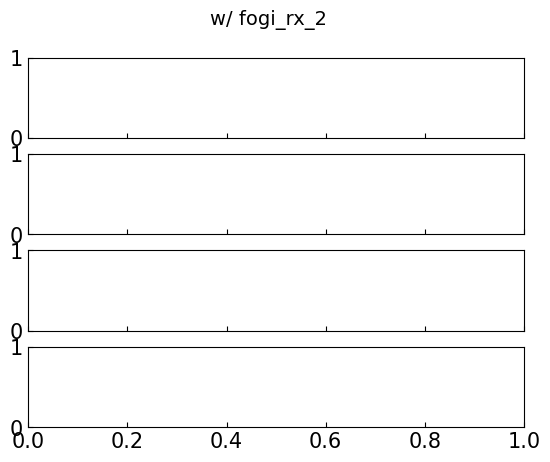

In [92]:
time = waveform_complex(acquisition_10)[0]

fig, ax = plt.subplots(nrows=4, sharex=True)
fig.suptitle("w/ fogi_rx_2", fontsize=14) 
datasets = [acquisition_02, acquisition_12, acquisition_22, acquisition_32]
for i in range(4):
    y_data = datasets[i].get_results()["waveform"][ph_amp][fogi_freq]
    ax[i].plot(time, y_data*1e4)
    ax[i].tick_params(labelbottom=(i == 3))
    ax[i].set_ylim(-2, 2)  
    ax[i].text(time.min(), ax[i].get_ylim()[1] * 0.9, f"fogi_tx_{i}",
               fontsize=12, ha="left", va="top",
               bbox=dict(facecolor="white", alpha=0.7))
ax[3].set_xlabel("Time (ns)", fontsize=12) 
fig.text(0.04, 0.5, "Amplitude (a.u.)", va="center", ha="center", rotation=90, fontsize=12)
plt.tight_layout(rect=[0.05, 0.05, 0, 0.95])
plt.show()

##################
m = overlap(waveform_complex(acquisition_02)[1], waveform_complex(acquisition_02)[1])
oth_00 = np.sqrt(1-(overlap(waveform_complex(acquisition_02)[1], waveform_complex(acquisition_02)[1])/m)**2)
oth_01 = np.sqrt(1-(overlap(waveform_complex(acquisition_02)[1], waveform_complex(acquisition_12)[1])/m)**2)
oth_03 = np.sqrt(1-(overlap(waveform_complex(acquisition_02)[1], waveform_complex(acquisition_32)[1])/m)**2)
oth_13 = np.sqrt(1-(overlap(waveform_complex(acquisition_12)[1], waveform_complex(acquisition_32)[1])/m)**2)

data = np.array([[oth_03, oth_13, np.nan, np.nan],
        [np.nan, np.nan, np.nan, np.nan],
        [oth_01, np.nan, np.nan, np.nan],
        [oth_00, np.nan, np.nan, np.nan]])
extent = (0, 3, 0, 3)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.imshow(data, extent=extent, filternorm=False, vmin=0, vmax=1)
colorbar = plt.colorbar(label="Orthogonality $O_{nm}$")
colorbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.ylabel("fogi_tx mode n")
plt.xlabel("fogi_tx mode m")

num_x_ticks = data.shape[1]
num_y_ticks = data.shape[0]
x_ticks = np.linspace(extent[0] + 0.37, extent[1] - 0.37, num_x_ticks)
y_ticks = np.linspace(extent[2] + 0.37, extent[3] - 0.37, num_y_ticks)
plt.xticks(x_ticks, range(num_x_ticks))
plt.yticks(y_ticks, range(num_y_ticks))
for i in range(num_y_ticks):
    for j in range(num_x_ticks):
        if j < 3-i:
            plt.text(x_ticks[i], 3-y_ticks[j], f"{np.round(data[j, i], decimals=4)}", ha='center', va='center', color="red")

plt.savefig('orthogonality.png', bbox_inches='tight')
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_18536\3978580161.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0.05, 0.05, 0, 0.95])


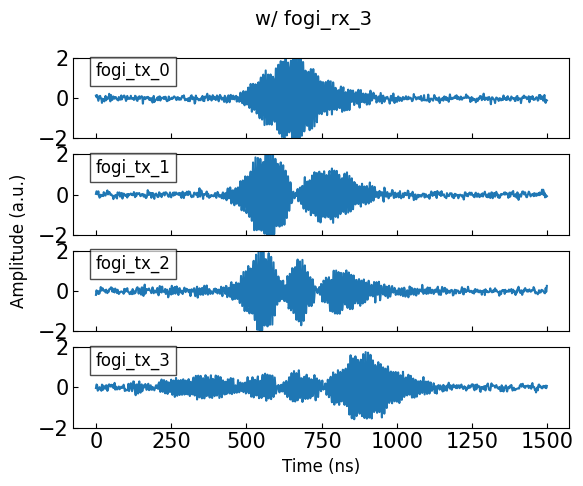

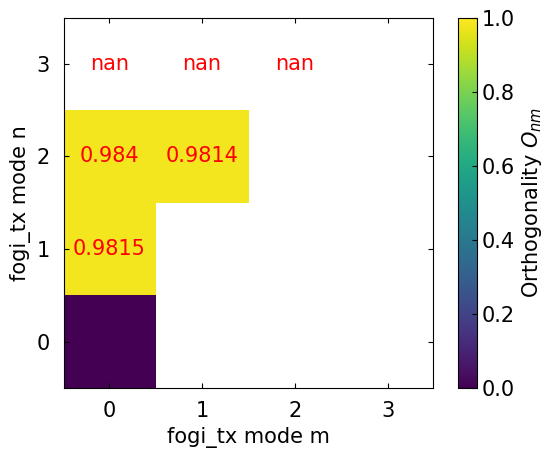

In [26]:
time = waveform_complex(acquisition_10)[0]

fig, ax = plt.subplots(nrows=4, sharex=True)
fig.suptitle("w/ fogi_rx_3", fontsize=14) 
datasets = [acquisition_03, acquisition_13, acquisition_23, acquisition_33]
for i in range(4):
    y_data = datasets[i].get_results()["waveform"][ph_amp][fogi_freq]
    ax[i].plot(time, y_data*1e4)
    ax[i].tick_params(labelbottom=(i == 3))
    ax[i].set_ylim(-2, 2) 
    ax[i].text(time.min(), ax[i].get_ylim()[1] * 0.9, f"fogi_tx_{i}",
               fontsize=12, ha="left", va="top",
               bbox=dict(facecolor="white", alpha=0.7))
ax[3].set_xlabel("Time (ns)", fontsize=12) 
fig.text(0.04, 0.5, "Amplitude (a.u.)", va="center", ha="center", rotation=90, fontsize=12)
plt.tight_layout(rect=[0.05, 0.05, 0, 0.95])
plt.show()

##################
m = overlap(waveform_complex(acquisition_03)[1], waveform_complex(acquisition_03)[1])
oth_00 = np.sqrt(1-(overlap(waveform_complex(acquisition_03)[1], waveform_complex(acquisition_03)[1])/m)**2)
oth_01 = np.sqrt(1-(overlap(waveform_complex(acquisition_03)[1], waveform_complex(acquisition_13)[1])/m)**2)
oth_02 = np.sqrt(1-(overlap(waveform_complex(acquisition_03)[1], waveform_complex(acquisition_23)[1])/m)**2)
oth_12 = np.sqrt(1-(overlap(waveform_complex(acquisition_13)[1], waveform_complex(acquisition_23)[1])/m)**2)

data = np.array([[np.nan, np.nan, np.nan, np.nan],
        [oth_02, oth_12, np.nan, np.nan],
        [oth_01, np.nan, np.nan, np.nan],
        [oth_00, np.nan, np.nan, np.nan]])
extent = (0, 3, 0, 3)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.imshow(data, extent=extent, filternorm=False, vmin=0, vmax=1)
colorbar = plt.colorbar(label="Orthogonality $O_{nm}$")
colorbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.ylabel("fogi_tx mode n")
plt.xlabel("fogi_tx mode m")

num_x_ticks = data.shape[1]
num_y_ticks = data.shape[0]
x_ticks = np.linspace(extent[0] + 0.37, extent[1] - 0.37, num_x_ticks)
y_ticks = np.linspace(extent[2] + 0.37, extent[3] - 0.37, num_y_ticks)
plt.xticks(x_ticks, range(num_x_ticks))
plt.yticks(y_ticks, range(num_y_ticks))
for i in range(num_y_ticks):
    for j in range(num_x_ticks):
        if j < 3-i:
            plt.text(x_ticks[i], 3-y_ticks[j], f"{np.round(data[j, i], decimals=4)}", ha='center', va='center', color="red")

plt.savefig('orthogonality.png', bbox_inches='tight')
plt.show()

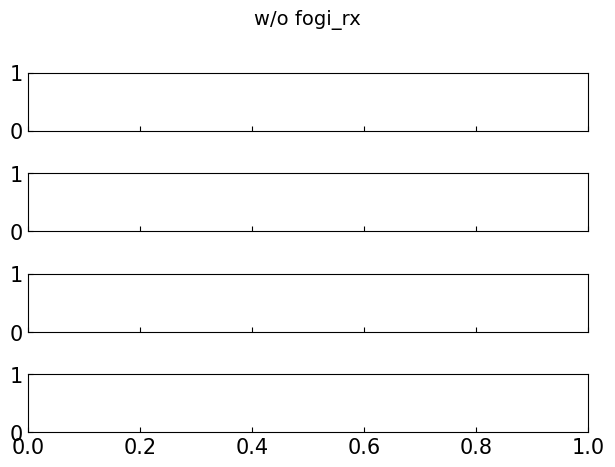

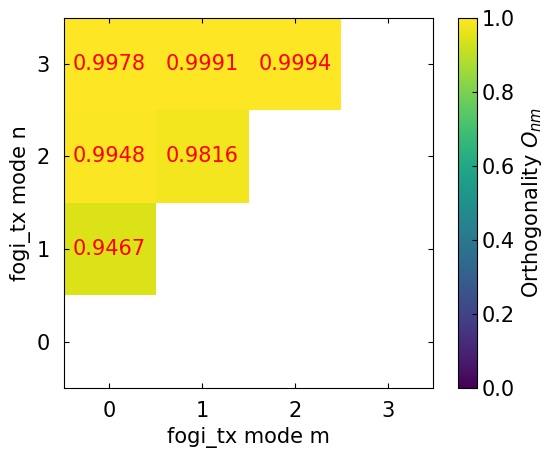

In [95]:
def waveform_complex1(data):
    time = data.get_results()["time"][ph_amp][fogi_freq]
    waveform = data.get_results()["waveform"][ph_amp][fogi_freq]
    phase = np.angle(demodulate(time, waveform, f_if*1e-9))
    waveform_complex = waveform * np.exp(-1j*phase)

    waveform_wo_fogi = data.get_results()["waveform_zero_fogi"][ph_amp][fogi_freq]
    phase_wo_fogi = np.angle(demodulate(time, waveform_wo_fogi, f_if*1e-9))
    waveform_complex_wo_fogi = waveform_wo_fogi * np.exp(-1j*phase_wo_fogi)
    return time, waveform_complex, waveform_complex_wo_fogi
time = waveform_complex(acquisition_00)[0]

fig, ax = plt.subplots(nrows=4, sharex=True)
fig.suptitle("w/o fogi_rx", fontsize=14) 
corrected_result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-18", acquire_time="163203", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-18", acquire_time="163240", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-18", acquire_time="163317", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-18", acquire_time="163355", form="sech_3"),
}
# fig, axes = plt.subplots(len(corrected_result_dict), 2, figsize=(8, 2 * len(corrected_result_dict)))
waveforms = []
for i, (k, v) in enumerate(corrected_result_dict.items()):
    ax, ax2 = axes[i]
    target_freq = v["target_freq"]
    form = v["form"]

    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time, waveform = start_stop(datadict["time"]["values"].ravel(), datadict["waveform"]["values"].ravel(), 0, duration)
    phase = np.angle(demodulate(time, waveform, f_if*1e-9))
    waveform_complex = waveform * np.exp(-1j*phase)
    waveforms.append(waveform_complex)

    # xfft, fourier = fourier_tr_padding(time, waveform)
    # xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    # photon_freq = readout_lo_freq + xfft

    # ax.plot(photon_freq, 10 * np.abs(fourier), label=f"data ({form})")
    # ax.vlines(target_freq, 0, 10 * max(np.abs(fourier)) * 1.1, color="r", ls="--", label="target")
    # ax.set_xlim(9.32, 9.38)
    # ax.set_xlabel("Photon Frequency (GHz)")
    # ax.set_ylabel("Amplitude (a.u.)")
    # ax.legend()

    # phase = np.angle(demodulate(time, waveform, readout_lo_freq - target_freq))
    # signal = 2 * lowpass(
    #     time, waveform * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
    #     passing_band, 0.03, 0.1, 90
    #     ) * np.exp(-1j * phase)
    # res = fit_waveform(time, np.abs(signal), curve=f"{form}")

    # ax2.plot(time, 1000 * waveform, "tab:blue", lw=1, alpha=0.5)
    # ax2.plot(time, 1000 * np.abs(signal), "tab:blue", lw=3, label=f"data ({form})")
    # # ax2.plot(time, 1000 * res, "r--", lw=2, label="target", alpha=1)
    # ax2.set_xlabel("Time (ns)")
    # ax2.set_ylabel("Amplitude (a.u.)")
    # ax2.set_xlim(0, duration)
    # ax2.legend()

    # symmetry = iq_symmetry(signal, time)
    # overlap = target_overlap(signal, time, curve=f"{form}")
    # print(f"Form: {form}, Symmetry: {symmetry}, Overlap: {overlap}")

plt.tight_layout()
plt.show()

# for i in range(4):
#     y_data = datasets[i].get_results()["waveform_zero_fogi"][ph_amp][fogi_freq]
#     ax[i].plot(time, y_data*1e4)
#     ax[i].tick_params(labelbottom=(i == 3))
#     ax[i].set_ylim(-4, 4) 
#     ax[i].text(time.min(), ax[i].get_ylim()[1] * 0.9, f"fogi_tx_{i}",
#                fontsize=12, ha="left", va="top",
#                bbox=dict(facecolor="white", alpha=0.7))
# ax[3].set_xlabel("Time (ns)", fontsize=12) 
# fig.text(0.04, 0.5, "Amplitude (a.u.)", va="center", ha="center", rotation=90, fontsize=12)
# plt.tight_layout(rect=[0.05, 0.05, 0, 0.95])
# plt.show()

##################
m = overlap(waveforms[0], waveforms[0])
oth_01 = np.sqrt(1-(overlap(waveforms[0], waveforms[1])/m)**2)
oth_02 = np.sqrt(1-(overlap(waveforms[0], waveforms[2])/m)**2)
oth_03 = np.sqrt(1-(overlap(waveforms[0], waveforms[3])/m)**2)
oth_12 = np.sqrt(1-(overlap(waveforms[1], waveforms[2])/m)**2)
oth_13 = np.sqrt(1-(overlap(waveforms[1], waveforms[3])/m)**2)
oth_23 = np.sqrt(1-(overlap(waveforms[2], waveforms[3])/m)**2)

data = np.array([[oth_03, oth_13, oth_23, np.nan],
        [oth_02, oth_12, np.nan, np.nan],
        [oth_01, np.nan, np.nan, np.nan],
        [np.nan, np.nan, np.nan, np.nan]])
extent = (0, 3, 0, 3)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.imshow(data, extent=extent, filternorm=False, vmin=0, vmax=1)
colorbar = plt.colorbar(label="Orthogonality $O_{nm}$")
colorbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.ylabel("fogi_tx mode n")
plt.xlabel("fogi_tx mode m")

num_x_ticks = data.shape[1]
num_y_ticks = data.shape[0]
x_ticks = np.linspace(extent[0] + 0.37, extent[1] - 0.37, num_x_ticks)
y_ticks = np.linspace(extent[2] + 0.37, extent[3] - 0.37, num_y_ticks)
plt.xticks(x_ticks, range(num_x_ticks))
plt.yticks(y_ticks, range(num_y_ticks))
for i in range(num_y_ticks):
    for j in range(num_x_ticks):
        if j < 3-i:
            plt.text(x_ticks[i], 3-y_ticks[j], f"{np.round(data[j, i], decimals=4)}", ha='center', va='center', color="red")

plt.show()

<Figure size 640x480 with 0 Axes>

C:\Users\qipe\AppData\Local\Temp\ipykernel_12228\1273041419.py:42: RuntimeWarning: invalid value encountered in sqrt
  oth_00 = np.sqrt(1-np.abs(overlap(waveforms_tx[0], waveforms_rx[0][::-1])/m)**2)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


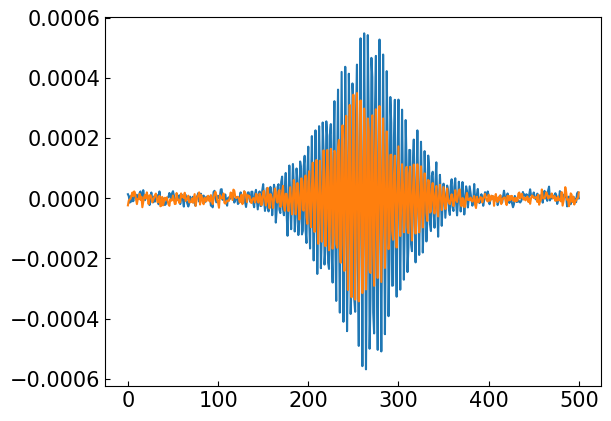

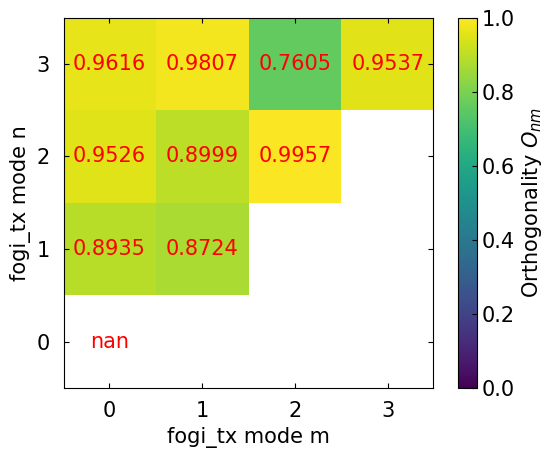

In [110]:

corrected_result_dict_tx = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-18", acquire_time="105702", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-18", acquire_time="105752", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-18", acquire_time="105842", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-18", acquire_time="105932", form="sech_3"),
}
corrected_result_dict_rx = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-18", acquire_time="163203", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-18", acquire_time="163240", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-18", acquire_time="163317", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-18", acquire_time="163355", form="sech_3"),
}
# fig, axes = plt.subplots(len(corrected_result_dict), 2, figsize=(8, 2 * len(corrected_result_dict)))
waveforms_tx = []
for i, (k, v) in enumerate(corrected_result_dict_tx.items()):
    target_freq = v["target_freq"]
    form = v["form"]

    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time, waveform = start_stop(datadict["time"]["values"].ravel(), datadict["waveform"]["values"].ravel(), 0, duration)
    phase = np.angle(demodulate(time, waveform, f_if*1e-9))
    waveform_complex = waveform * np.exp(-1j*phase)
    waveforms_tx.append(waveform_complex)

waveforms_rx = []
for i, (k, v) in enumerate(corrected_result_dict_rx.items()):
    target_freq = v["target_freq"]
    form = v["form"]

    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time, waveform = start_stop(datadict["time"]["values"].ravel(), datadict["waveform"]["values"].ravel(), 0, duration)
    phase = np.angle(demodulate(time, waveform, f_if*1e-9))
    waveform_complex = waveform * np.exp(-1j*phase)
    waveforms_rx.append(waveform_complex)

plt.tight_layout()
plt.show()


##################
m = overlap(waveforms_tx[0], waveforms_tx[0])
oth_00 = np.sqrt(1-np.abs(overlap(waveforms_tx[0], waveforms_rx[0][::-1])/m)**2)

plt.plot(waveforms_rx[0])
plt.plot(waveforms_tx[0])
plt.show()
oth_01 = np.sqrt(1-np.abs(overlap(waveforms_tx[0], waveforms_rx[1][::-1])/m)**2)
oth_02 = np.sqrt(1-np.abs(overlap(waveforms_tx[0], waveforms_rx[2][::-1])/m)**2)
oth_03 = np.sqrt(1-np.abs(overlap(waveforms_tx[0], waveforms_rx[3][::-1])/m)**2)
oth_11 = np.sqrt(1-np.abs(overlap(waveforms_tx[1], waveforms_rx[1][::-1])/m)**2)
oth_12 = np.sqrt(1-np.abs(overlap(waveforms_tx[1], waveforms_rx[2][::-1])/m)**2)
oth_13 = np.sqrt(1-np.abs(overlap(waveforms_tx[1], waveforms_rx[3][::-1])/m)**2)
oth_22 = np.sqrt(1-np.abs(overlap(waveforms_tx[2], waveforms_rx[2][::-1])/m)**2)
oth_23 = np.sqrt(1-np.abs(overlap(waveforms_tx[2], waveforms_rx[3][::-1])/m)**2)
oth_33 = np.sqrt(1-np.abs(overlap(waveforms_tx[3], waveforms_rx[3][::-1])/m)**2)

data = np.array([[oth_03, oth_13, oth_23, oth_33],
        [oth_02, oth_12, oth_22, np.nan],
        [oth_01, oth_11, np.nan, np.nan],
        [oth_00, np.nan, np.nan, np.nan]])
extent = (0, 3, 0, 3)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.imshow(data, extent=extent, filternorm=False, vmin=0, vmax=1)
colorbar = plt.colorbar(label="Orthogonality $O_{nm}$")
colorbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.ylabel("fogi_tx mode n")
plt.xlabel("fogi_tx mode m")

num_x_ticks = data.shape[1]
num_y_ticks = data.shape[0]
x_ticks = np.linspace(extent[0] + 0.37, extent[1] - 0.37, num_x_ticks)
y_ticks = np.linspace(extent[2] + 0.37, extent[3] - 0.37, num_y_ticks)
plt.xticks(x_ticks, range(num_x_ticks))
plt.yticks(y_ticks, range(num_y_ticks))
for i in range(num_y_ticks):
    for j in range(num_x_ticks):
        if j <= 3-i:
            plt.text(x_ticks[i], 3-y_ticks[j], f"{np.round(data[j, i], decimals=4)}", ha='center', va='center', color="red")

plt.show()

In [103]:
1-(overlap(waveforms_tx[0], waveforms_rx[0])/m)**2

-1.0768581669675417